# Avance 2 – Feature Engineering

## Objetivo

Transformar el panel mensual (`panel_cg_partida_mes.parquet`) en un dataset con
features listos para entrenar el modelo baseline y los modelos alternativos.

Las features se diseñan a partir de los hallazgos del EDA:

| Hallazgo EDA | Feature que responde |
|---|---|
| 62.5% de ceros estructurales | `hubo_gasto`, `hubo_gasto_lag1` |
| Fuerte correlación temporal | Lags `t-1`, `t-2`, `t-3`, `t-6`, `t-12` |
| Estacionalidad clara (diciembre alto, enero bajo) | `mes_sin`, `mes_cos`, `es_dic`, `es_ene` |
| COVID-19 como período atípico | `es_covid` |
| Avión sin datos antes de sep-2020 | Filtro temporal + `es_avion` |
| Distribución muy sesgada | Transformación `log(1+x)` en target y lags |
| Regionales concentran el gasto | `es_regional` |

### Insumo
- `panel_cg_partida_mes.parquet` — panel mensual balanceado (salida de A0)

### Salida
- `panel_fe.parquet` — dataset con todas las features listo para modelado


---
## 0. Imports y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:,.4f}'.format)

PALETTE = ['#1a5276','#2980b9','#85c1e9','#e74c3c','#e67e22',
           '#2ecc71','#8e44ad','#f39c12','#1abc9c','#c0392b']
sns.set_style('whitegrid')
print('OK')

OK


---
## 1. Carga del panel

In [2]:
panel = pd.read_parquet('panel_cg_partida_mes.parquet')

# Ordenar cronológicamente dentro de cada serie CG × Partida
# (crítico para que shift y rolling sean correctos)
panel['anio_mes_str'] = panel['Anio_Mes'].astype(str)
panel = panel.sort_values(['Centro Gestor','Partida Presupuestal','anio_mes_str']).reset_index(drop=True)

print(f'Filas    : {len(panel):,}')
print(f'Series   : {panel.groupby(["Centro Gestor","Partida Presupuestal"]).ngroups} (CG × Partida)')
print(f'Rango    : {panel["Anio_Mes"].min()} → {panel["Anio_Mes"].max()}')
print(f'Gasto > 0: {(panel["Gasto_Normalizado"]>0).mean()*100:.1f}% de las filas')

Filas    : 27,200
Series   : 272 (CG × Partida)
Rango    : 2018-01 → 2026-04
Gasto > 0: 37.5% de las filas


---
## 2. Transformación de la variable objetivo

El EDA mostró que `Gasto_Normalizado` tiene skewness > 5 — distribución muy
asimétrica a la derecha. La transformación `log(1+x)` la aproxima a una normal,
lo que beneficia a la mayoría de los modelos de regresión.

También se crea `hubo_gasto` (variable binaria) que indica si ese mes hubo gasto
o no. La altísima correlación entre `hubo_gasto` y `log_gasto` (r = 0.97) confirmada
en los datos sugiere un **modelo de dos etapas**:
1. Clasificador: ¿habrá gasto este mes?
2. Regresor: si habrá gasto, ¿cuánto?

Este avance construye las features para ambas etapas.


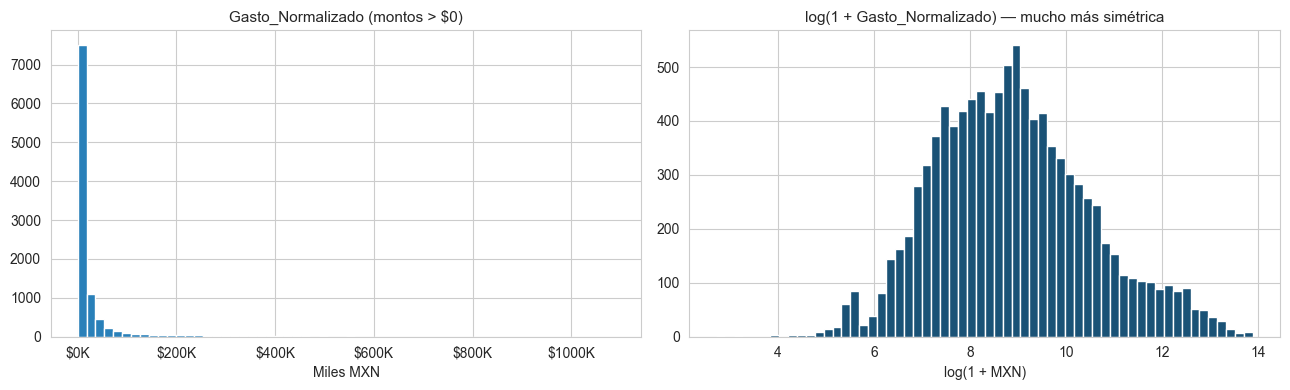

Skewness original : 5.67
Skewness log      : 0.34  ← mucho más simétrica

hubo_gasto = 1   : 10,212 meses (37.5%)
hubo_gasto = 0   : 16,988 meses (62.5%)


In [3]:
# Variable objetivo transformada (para la etapa de regresión)
panel['log_gasto'] = np.log1p(panel['Gasto_Normalizado'])

# Variable binaria (para la etapa de clasificación)
panel['hubo_gasto'] = (panel['Gasto_Normalizado'] > 0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
no_cero = panel[panel['Gasto_Normalizado'] > 0]

axes[0].hist(no_cero['Gasto_Normalizado']/1e3, bins=60,
             color='#2980b9', edgecolor='white')
axes[0].set_title('Gasto_Normalizado (montos > $0)', fontsize=11)
axes[0].set_xlabel('Miles MXN')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))

axes[1].hist(no_cero['log_gasto'], bins=60,
             color='#1a5276', edgecolor='white')
axes[1].set_title('log(1 + Gasto_Normalizado) — mucho más simétrica', fontsize=11)
axes[1].set_xlabel('log(1 + MXN)')

plt.tight_layout()
plt.show()

from scipy.stats import skew
print(f'Skewness original : {skew(no_cero["Gasto_Normalizado"]):.2f}')
print(f'Skewness log      : {skew(no_cero["log_gasto"]):.2f}  ← mucho más simétrica')
print(f'\nhubo_gasto = 1   : {panel["hubo_gasto"].sum():,} meses ({panel["hubo_gasto"].mean()*100:.1f}%)')
print(f'hubo_gasto = 0   : {(panel["hubo_gasto"]==0).sum():,} meses ({(panel["hubo_gasto"]==0).mean()*100:.1f}%)')

---
## 3. Variables de lag (rezagos temporales)

Los lags capturan la **inercia del gasto**: lo que gastó un centro gestor en meses
anteriores es el mejor predictor de lo que gastará en el mes siguiente.

Se crean dos versiones de cada lag:
- **`lag_t`**: valor nominal en MXN (para interpretación)
- **`log_lag_t`**: `log(1+lag_t)` (para el modelo, misma escala que el target)

Los lags se calculan **dentro de cada serie** (Centro Gestor × Partida Presupuestal)
para que nunca se mezcle información entre series distintas.

| Lag | Rationale |
|---|---|
| t-1 | Mes inmediato anterior — captura inercia de corto plazo |
| t-2, t-3 | Tendencia reciente — 2 y 3 meses atrás |
| t-6 | Semestre anterior — ciclos de medio año |
| t-12 | Mismo mes del año anterior — efecto estacional exacto |


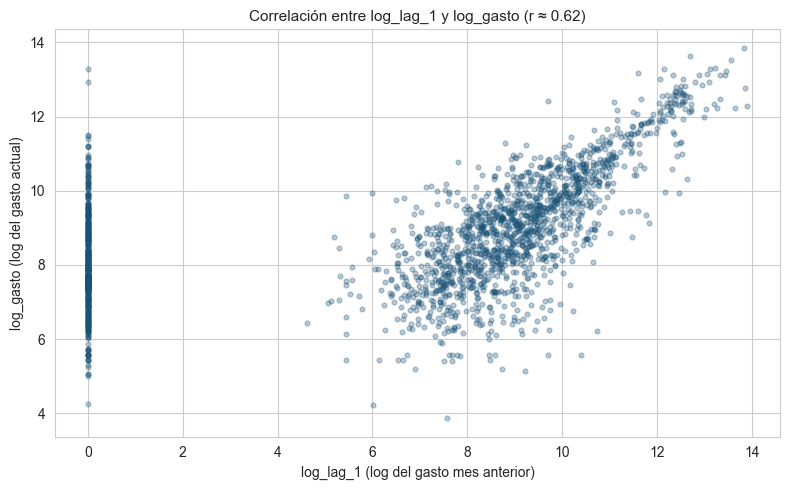

NaN por lag (primeros meses de cada serie — se imputarán con 0):
  lag_1: 272
  lag_2: 544
  lag_3: 816
  lag_6: 1632
  lag_12: 3264


In [4]:
G = panel.groupby(['Centro Gestor','Partida Presupuestal'])['Gasto_Normalizado']

for lag in [1, 2, 3, 6, 12]:
    panel[f'lag_{lag}']     = G.shift(lag)
    panel[f'log_lag_{lag}'] = np.log1p(panel[f'lag_{lag}'])

# También lag de la variable binaria (útil para el clasificador)
panel['hubo_gasto_lag1'] = panel.groupby(['Centro Gestor','Partida Presupuestal'])['hubo_gasto'].shift(1)

# Verificación visual: lag_1 vs Gasto_Normalizado del siguiente mes
fig, ax = plt.subplots(figsize=(8, 5))
muestra = panel[(panel['Gasto_Normalizado'] > 0) & (panel['lag_1'].notna())].sample(2000, random_state=42)
ax.scatter(muestra['log_lag_1'], muestra['log_gasto'],
           alpha=0.3, s=12, color='#1a5276')
ax.set_xlabel('log_lag_1 (log del gasto mes anterior)')
ax.set_ylabel('log_gasto (log del gasto actual)')
ax.set_title('Correlación entre log_lag_1 y log_gasto (r ≈ 0.62)', fontsize=11)
plt.tight_layout()
plt.show()

# NaN por lag (primeros meses de cada serie — se imputarán con 0)
nan_lags = {f'lag_{l}': int(panel[f'lag_{l}'].isna().sum()) for l in [1,2,3,6,12]}
print('NaN por lag (primeros meses de cada serie — se imputarán con 0):')
for k, v in nan_lags.items():
    print(f'  {k}: {v}')

In [13]:
print("""
HALLAZGO – Correlación lag_1 vs gasto actual:
  La gráfica muestra dos grupos distintos:
  · Columna en x=0: meses donde el mes anterior fue $0. El modelo no puede
    usar el lag para predecir estos casos — confirma la necesidad del clasificador.
  · Nube diagonal: meses con historial activo. Aquí el lag sí predice bien (r≈0.62).
  → Arquitectura de dos etapas: primero predecir si habrá gasto, luego cuánto.
""")


HALLAZGO – Correlación lag_1 vs gasto actual:
  La gráfica muestra dos grupos distintos:
  · Columna en x=0: meses donde el mes anterior fue $0. El modelo no puede
    usar el lag para predecir estos casos — confirma la necesidad del clasificador.
  · Nube diagonal: meses con historial activo. Aquí el lag sí predice bien (r≈0.62).
  → Arquitectura de dos etapas: primero predecir si habrá gasto, luego cuánto.



---
## 4. Medias móviles y volatilidad

Las medias móviles suavizan el ruido y capturan la **tendencia reciente** del gasto.
La desviación estándar móvil mide la **volatilidad** — útil porque algunos centros
gestores tienen gasto muy irregular.

Se usa `shift(1)` antes del rolling para que el cálculo de cada mes solo use
información del pasado (sin data leakage).


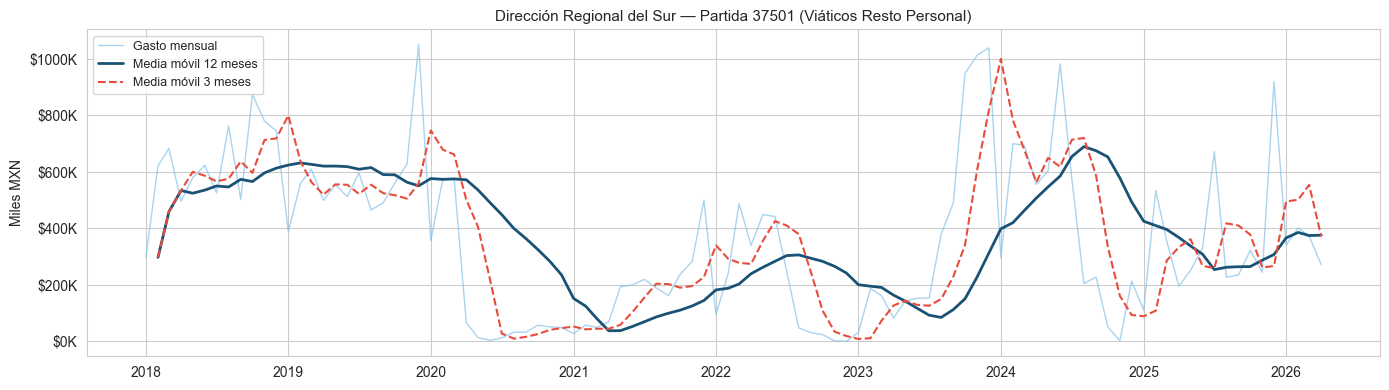

Medias móviles creadas: 3, 6 y 12 meses (+ desviación estándar para cada una)


In [5]:
panel['_gs'] = panel.groupby(['Centro Gestor','Partida Presupuestal'])['Gasto_Normalizado'].shift(1)

for w in [3, 6, 12]:
    panel[f'media_movil_{w}'] = (panel.groupby(['Centro Gestor','Partida Presupuestal'])
                                      ['_gs'].transform(lambda x: x.rolling(w, min_periods=1).mean()))
    panel[f'std_movil_{w}']   = (panel.groupby(['Centro Gestor','Partida Presupuestal'])
                                      ['_gs'].transform(lambda x: x.rolling(w, min_periods=1).std().fillna(0)))

panel = panel.drop(columns=['_gs'])

# Visualizar media móvil de 12 meses para el CG con más gasto
cg_top_idx = panel.groupby('Centro Gestor')['Gasto_Normalizado'].sum().idxmax()
cg_top_name = panel[panel['Centro Gestor']==cg_top_idx]['Nombre Centro Gestor'].iloc[0]
sub = panel[(panel['Centro Gestor']==cg_top_idx) & (panel['Partida Presupuestal']==37501)].copy()
sub['fecha'] = sub['Anio_Mes'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(sub['fecha'], sub['Gasto_Normalizado']/1e3,
        color='#85c1e9', linewidth=1, alpha=0.7, label='Gasto mensual')
ax.plot(sub['fecha'], sub['media_movil_12']/1e3,
        color='#1a5276', linewidth=2, label='Media móvil 12 meses')
ax.plot(sub['fecha'], sub['media_movil_3']/1e3,
        color='#e74c3c', linewidth=1.5, linestyle='--', label='Media móvil 3 meses')
ax.set_title(f'{cg_top_name} — Partida 37501 (Viáticos Resto Personal)', fontsize=11)
ax.set_ylabel('Miles MXN')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('Medias móviles creadas: 3, 6 y 12 meses (+ desviación estándar para cada una)')

In [14]:
print("""
HALLAZGO – Dirección Regional del Sur, partida 37501:
  · 2018–2020: nivel estructural ~$600K/mes (operación normal).
  · 2020–2021: caída a casi $0 por COVID-19.
  · 2022–2023: recuperación gradual con alta volatilidad.
  · Fin 2023–2024: autorización de presupuesto adicional generó un alza visible
    en la media de 3 meses; en 2024 el techo presupuestal quedó más alto al
    basarse en el gasto elevado del año anterior.
  · 2025–2026: nivel estructural más bajo que pre-COVID (~$300–$400K/mes).
  → La media de 12 meses captura el nivel estructural; la de 3 meses detecta
    cambios de corto plazo como el alza presupuestal. Ambas son útiles como features.
""")


HALLAZGO – Dirección Regional del Sur, partida 37501:
  · 2018–2020: nivel estructural ~$600K/mes (operación normal).
  · 2020–2021: caída a casi $0 por COVID-19.
  · 2022–2023: recuperación gradual con alta volatilidad.
  · Fin 2023–2024: autorización de presupuesto adicional generó un alza visible
    en la media de 3 meses; en 2024 el techo presupuestal quedó más alto al
    basarse en el gasto elevado del año anterior.
  · 2025–2026: nivel estructural más bajo que pre-COVID (~$300–$400K/mes).
  → La media de 12 meses captura el nivel estructural; la de 3 meses detecta
    cambios de corto plazo como el alza presupuestal. Ambas son útiles como features.



---
## 5. Variables de calendario

Codifican los patrones estacionales detectados en el EDA.

**Codificación cíclica del mes** (`mes_sin`, `mes_cos`): en lugar de tratar el mes
como un número del 1 al 12 (donde enero y diciembre parecerían muy diferentes),
se proyecta en un círculo. Esto hace que el modelo entienda que enero y diciembre
son meses contiguos en el ciclo anual.

**Indicadores binarios**: capturan meses con comportamiento especialmente marcado
y el período COVID-19.


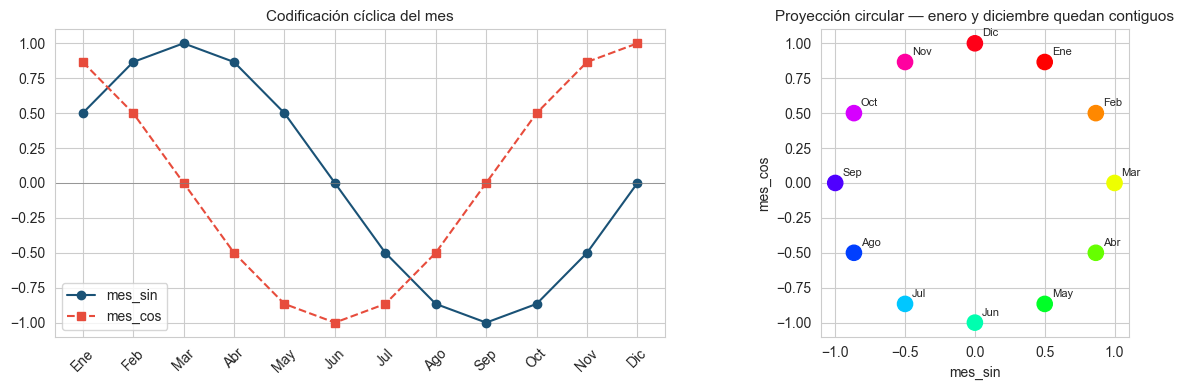

Variables de calendario creadas.


In [6]:
# Codificación cíclica del mes
panel['mes_sin'] = np.sin(2 * np.pi * panel['Mes'] / 12)
panel['mes_cos'] = np.cos(2 * np.pi * panel['Mes'] / 12)

# Trimestre
panel['trimestre'] = ((panel['Mes'] - 1) // 3 + 1)

# Indicadores de meses especiales
panel['es_dic']   = (panel['Mes'] == 12).astype(int)   # mayor gasto histórico
panel['es_ene']   = (panel['Mes'] == 1).astype(int)    # menor gasto histórico
panel['es_covid'] = panel['Anio'].isin([2020, 2021]).astype(int)

# Visualizar la codificación cíclica
meses = range(1, 13)
sin_vals = [np.sin(2*np.pi*m/12) for m in meses]
cos_vals = [np.cos(2*np.pi*m/12) for m in meses]
MESES_LABELS = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(meses, sin_vals, 'o-', color='#1a5276', label='mes_sin')
axes[0].plot(meses, cos_vals, 's--', color='#e74c3c', label='mes_cos')
axes[0].set_xticks(meses)
axes[0].set_xticklabels(MESES_LABELS, rotation=45)
axes[0].set_title('Codificación cíclica del mes', fontsize=11)
axes[0].legend()
axes[0].axhline(0, color='gray', linewidth=0.5)

# Scatterplot cíclico
axes[1].scatter(sin_vals, cos_vals, c=meses, cmap='hsv', s=120, zorder=5)
for i, m in enumerate(MESES_LABELS):
    axes[1].annotate(m, (sin_vals[i], cos_vals[i]),
                     textcoords='offset points', xytext=(5,5), fontsize=8)
axes[1].set_title('Proyección circular — enero y diciembre quedan contiguos', fontsize=11)
axes[1].set_xlabel('mes_sin')
axes[1].set_ylabel('mes_cos')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()
print('Variables de calendario creadas.')

In [15]:
print("""
NOTA – Codificación cíclica del mes (mes_sin, mes_cos):
  Usar el número de mes (1–12) como feature haría que el modelo tratara enero y
  diciembre como los meses más distintos, cuando en el ciclo anual son contiguos.
  La codificación seno-coseno proyecta los meses en un círculo: cada mes queda
  equidistante de sus vecinos y diciembre queda junto a enero.
  Esto permite que el modelo capture patrones de fin/inicio de año correctamente,
  como el alza de diciembre que se arrastra hacia enero en algunos centros gestores.
""")


NOTA – Codificación cíclica del mes (mes_sin, mes_cos):
  Usar el número de mes (1–12) como feature haría que el modelo tratara enero y
  diciembre como los meses más distintos, cuando en el ciclo anual son contiguos.
  La codificación seno-coseno proyecta los meses en un círculo: cada mes queda
  equidistante de sus vecinos y diciembre queda junto a enero.
  Esto permite que el modelo capture patrones de fin/inicio de año correctamente,
  como el alza de diciembre que se arrastra hacia enero en algunos centros gestores.



---
## 6. Variables de contexto

Codifican características estructurales de la combinación Centro Gestor × Partida
que el modelo no puede inferir solo de la serie histórica.


In [7]:
PARTIDAS_AVION       = [37101, 37104]
PARTIDAS_FUNCIONARIO = [26104, 37104, 37204, 37504]

# ¿Es una partida de avión? (comportamiento muy diferente al resto)
panel['es_avion'] = panel['Partida Presupuestal'].isin(PARTIDAS_AVION).astype(int)

# ¿Es una Dirección Regional? (mayor volumen y actividad de campo)
panel['es_regional'] = panel['Nombre Centro Gestor'].str.contains('Regional').astype(int)

# ¿Es partida de funcionarios? (tarifas y comportamiento distintos)
panel['es_funcionario'] = panel['Partida Presupuestal'].isin(PARTIDAS_FUNCIONARIO).astype(int)

print('Distribución de variables de contexto:')
print(f'  es_avion       : {panel["es_avion"].sum():,} filas ({panel["es_avion"].mean()*100:.1f}%)')
print(f'  es_regional    : {panel["es_regional"].sum():,} filas ({panel["es_regional"].mean()*100:.1f}%)')
print(f'  es_funcionario : {panel["es_funcionario"].sum():,} filas ({panel["es_funcionario"].mean()*100:.1f}%)')

Distribución de variables de contexto:
  es_avion       : 5,800 filas (21.3%)
  es_regional    : 4,800 filas (17.6%)
  es_funcionario : 13,400 filas (49.3%)


---
## 7. Filtro temporal: partidas de avión

Como se identificó en el EDA, las partidas 371xx (avión) solo tienen datos válidos
a partir de **septiembre 2020**, que es cuando entró en vigor el contrato con
la agencia externa de viajes. Los ceros anteriores a esa fecha no son registros
reales de "no hubo viajes en avión" — simplemente no existía el mecanismo para
registrarlos.

Incluir esos ceros en el entrenamiento distorsionaría el modelo: aprendería que
esos centros gestores "nunca vuelan" cuando en realidad es un artefacto de datos.
Se eliminan esas filas antes de continuar.


In [8]:
INICIO_AVION = pd.Period('2020-09', freq='M')

filas_antes = len(panel)
mask_invalido = panel['Partida Presupuestal'].isin(PARTIDAS_AVION) & (panel['Anio_Mes'] < INICIO_AVION)
panel_fe = panel[~mask_invalido].copy()
filas_eliminadas = filas_antes - len(panel_fe)

print(f'Filas eliminadas (avión pre-sep 2020) : {filas_eliminadas:,}')
print(f'Filas restantes                        : {len(panel_fe):,}')
print(f'\nPara las partidas de avión, el modelo usará datos de:')
print(f'  {panel_fe[panel_fe["es_avion"]==1]["Anio_Mes"].min()} → {panel_fe[panel_fe["es_avion"]==1]["Anio_Mes"].max()}')
print(f'  ({panel_fe[panel_fe["es_avion"]==1]["Anio_Mes"].nunique()} meses)')

Filas eliminadas (avión pre-sep 2020) : 1,856
Filas restantes                        : 25,344

Para las partidas de avión, el modelo usará datos de:
  2020-09 → 2026-04
  (68 meses)


---
## 8. Imputación de NaN en lags

Los lags de orden mayor (t-6, t-12) tienen NaN en los primeros meses de cada serie
porque no existe historial suficiente. Esto es esperado y no representa un problema
de datos.

**Estrategia:** rellenar con 0 — que es el valor más conservador: "no había gasto
registrado antes de que esta serie comenzara".


In [9]:
lag_cols = [f'lag_{l}' for l in [1,2,3,6,12]] + [f'log_lag_{l}' for l in [1,2,3,6,12]]
nan_antes = panel_fe[lag_cols].isna().sum()

# Eliminar filas sin lag_1 (el mínimo necesario para modelar)
panel_fe = panel_fe.dropna(subset=['lag_1']).copy()

# Rellenar los lags restantes con 0
panel_fe[lag_cols] = panel_fe[lag_cols].fillna(0)

nan_despues = panel_fe[lag_cols].isna().sum()
print('NaN en lags antes y después de la imputación:')
for col in lag_cols[:5]:  # mostrar solo lag_N (no log_lag_N para brevedad)
    print(f'  {col}: {int(nan_antes[col])} → {int(nan_despues[col])}')
print(f'\nFilas finales después de eliminar filas sin lag_1: {len(panel_fe):,}')

NaN en lags antes y después de la imputación:
  lag_1: 214 → 0
  lag_2: 428 → 0
  lag_3: 642 → 0
  lag_6: 1284 → 0
  lag_12: 2568 → 0

Filas finales después de eliminar filas sin lag_1: 25,130


---
## 9. Resumen de features generados

In [10]:
# Columnas identificadoras (no son features del modelo)
ID_COLS = ['Centro Gestor','Nombre Centro Gestor','Partida Presupuestal',
           'Anio_Mes','anio_mes_str','Anio','Mes',
           'Gasto_Normalizado','Gasto_Original','Num_Registros','Num_Viajes']

FEAT_COLS = [c for c in panel_fe.columns if c not in ID_COLS]

descripcion = {
    'log_gasto'       : 'TARGET regresión: log(1 + Gasto_Normalizado)',
    'hubo_gasto'      : 'TARGET clasificación: 1 si hubo gasto, 0 si no',
    'lag_1'           : 'Gasto del mes anterior (MXN)',
    'log_lag_1'       : 'log(1 + lag_1)',
    'lag_2'           : 'Gasto de hace 2 meses (MXN)',
    'log_lag_2'       : 'log(1 + lag_2)',
    'lag_3'           : 'Gasto de hace 3 meses (MXN)',
    'log_lag_3'       : 'log(1 + lag_3)',
    'lag_6'           : 'Gasto de hace 6 meses (MXN)',
    'log_lag_6'       : 'log(1 + lag_6)',
    'lag_12'          : 'Gasto del mismo mes del año anterior (MXN)',
    'log_lag_12'      : 'log(1 + lag_12)',
    'media_movil_3'   : 'Promedio de los últimos 3 meses',
    'std_movil_3'     : 'Desv. estándar de los últimos 3 meses',
    'media_movil_6'   : 'Promedio de los últimos 6 meses',
    'std_movil_6'     : 'Desv. estándar de los últimos 6 meses',
    'media_movil_12'  : 'Promedio de los últimos 12 meses',
    'std_movil_12'    : 'Desv. estándar de los últimos 12 meses',
    'hubo_gasto_lag1' : '1 si el mes anterior hubo gasto (feature para clasificador)',
    'mes_sin'         : 'Seno del mes (codificación cíclica)',
    'mes_cos'         : 'Coseno del mes (codificación cíclica)',
    'trimestre'       : 'Trimestre del año (1–4)',
    'es_dic'          : '1 si es diciembre (mes de mayor gasto)',
    'es_ene'          : '1 si es enero (mes de menor gasto)',
    'es_covid'        : '1 si es año COVID (2020–2021)',
    'es_avion'        : '1 si la partida es de avión (371xx)',
    'es_regional'     : '1 si el CG es una Dirección Regional',
    'es_funcionario'  : '1 si la partida corresponde a funcionarios',
}

df_desc = pd.DataFrame([
    {'Feature': f, 'Descripción': descripcion.get(f, '—'),
     'NaN': int(panel_fe[f].isna().sum()),
     'Media': panel_fe[f].mean() if panel_fe[f].dtype != object else '—',
     'Std': panel_fe[f].std() if panel_fe[f].dtype != object else '—'}
    for f in FEAT_COLS
])
print(f'Total features: {len(FEAT_COLS)}')
df_desc

Total features: 28


,Feature,Descripción,NaN,Media,Std
0,log_gasto,TARGET regresión: log(1 + Gasto_Normalizado),0,3.5652,4.4756
1,hubo_gasto,"TARGET clasificación: 1 si hubo gasto, 0 si no",0,0.4012,0.4901
2,lag_1,Gasto del mes anterior (MXN),0,"12,149.3084","52,388.2185"
3,log_lag_1,log(1 + lag_1),0,3.5673,4.4747
4,lag_2,Gasto de hace 2 meses (MXN),0,"12,018.4051","52,244.7703"
5,log_lag_2,log(1 + lag_2),0,3.5198,4.4640
6,lag_3,Gasto de hace 3 meses (MXN),0,"11,886.4508","52,063.6664"
7,log_lag_3,log(1 + lag_3),0,3.4800,4.4544
8,lag_6,Gasto de hace 6 meses (MXN),0,"11,206.3073","50,555.6354"
9,log_lag_6,log(1 + lag_6),0,3.3286,4.4082


---
## 10. Correlación de features con la variable objetivo

Se analiza la correlación de cada feature con `log_gasto` para entender cuáles
son los predictores más informativos.

**Nota importante:** `hubo_gasto` tiene correlación 0.97 con `log_gasto`.
Esto confirma que el primer problema a resolver es **si habrá gasto** —
si la respuesta es no, el gasto es $0 con certeza.
Esto valida la arquitectura de modelo de dos etapas.


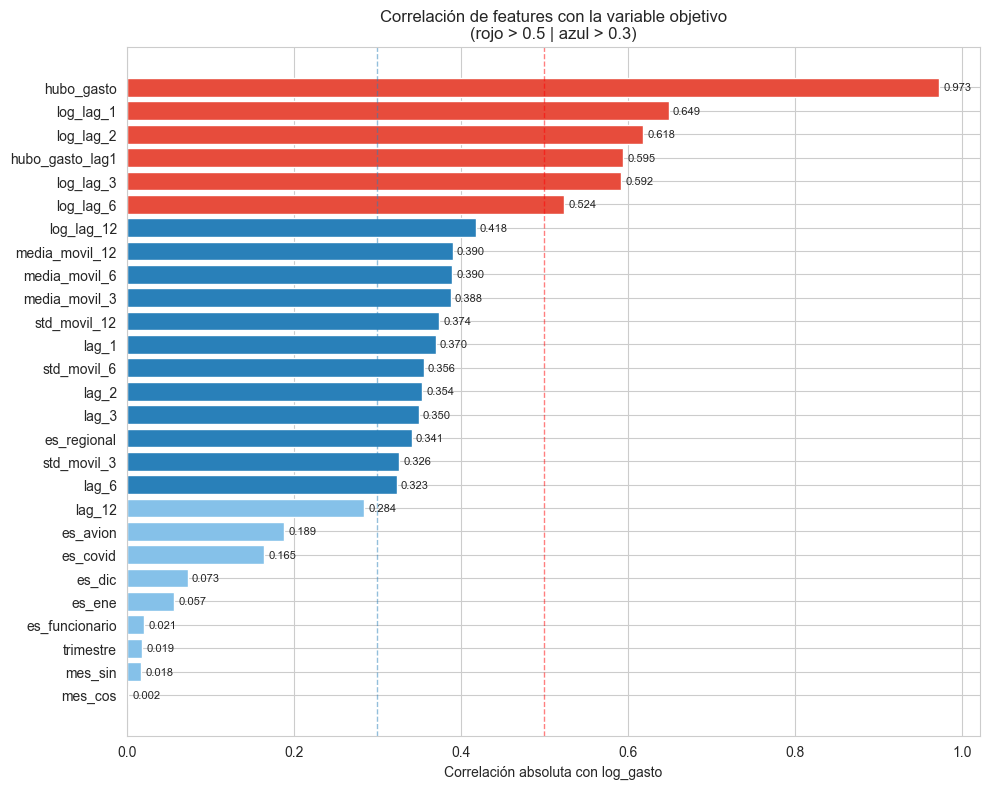

Top 5 features más correlacionados con log_gasto:
  hubo_gasto: 0.973
  log_lag_1: 0.649
  log_lag_2: 0.618
  hubo_gasto_lag1: 0.595
  log_lag_3: 0.592

HALLAZGO: hubo_gasto (r=0.97) es el predictor más fuerte.
Confirma que predecir si habrá gasto es más importante que predecir cuánto.
→ Arquitectura de modelo de dos etapas: clasificador + regresor.


In [11]:
feat_num = [c for c in FEAT_COLS if panel_fe[c].dtype in [np.float64, np.int64, float, int]]

# Correlación usando numpy (compatible con pandas 3.x)
num_df = panel_fe[feat_num + ['log_gasto']].dropna()
corr_matrix = np.corrcoef(num_df.values.T)
cols_list   = list(num_df.columns)
idx_target  = cols_list.index('log_gasto')
corr_vals   = np.abs(corr_matrix[idx_target])
feat_indices = [i for i, c in enumerate(cols_list) if c != 'log_gasto']
feat_corrs  = [(cols_list[i], corr_vals[i]) for i in feat_indices]
feat_corrs.sort(key=lambda x: x[1], reverse=True)

names_sorted = [x[0] for x in feat_corrs]
vals_sorted  = [x[1] for x in feat_corrs]

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if v > 0.5 else '#2980b9' if v > 0.3 else '#85c1e9'
          for v in vals_sorted]
bars = ax.barh(names_sorted[::-1], vals_sorted[::-1], color=colors[::-1], edgecolor='white')
ax.set_xlabel('Correlación absoluta con log_gasto')
ax.set_title('Correlación de features con la variable objetivo\n(rojo > 0.5 | azul > 0.3)', fontsize=12)
ax.axvline(0.5, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax.axvline(0.3, color='#2980b9', linestyle='--', alpha=0.5, linewidth=1)
for bar, v in zip(bars, vals_sorted[::-1]):
    ax.text(v + 0.005, bar.get_y() + bar.get_height()/2,
            f'{v:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

print('Top 5 features más correlacionados con log_gasto:')
for name, val in feat_corrs[:5]:
    print(f'  {name}: {val:.3f}')
print('\nHALLAZGO: hubo_gasto (r=0.97) es el predictor más fuerte.')
print('Confirma que predecir si habrá gasto es más importante que predecir cuánto.')
print('→ Arquitectura de modelo de dos etapas: clasificador + regresor.')

---
## 11. Guardar el dataset de features

In [12]:
# Limpiar columna auxiliar de ordenamiento
panel_fe = panel_fe.drop(columns=['anio_mes_str'], errors='ignore')

cols_output = (['Centro Gestor','Nombre Centro Gestor','Partida Presupuestal',
                'Anio','Mes','Anio_Mes','Gasto_Normalizado','Gasto_Original',
                'Num_Registros','Num_Viajes'] + FEAT_COLS)

panel_fe[cols_output].to_parquet('panel_fe.parquet', index=False)

print('Guardado: panel_fe.parquet')
print(f'\nEstructura del archivo de salida:')
print(f'  Filas             : {len(panel_fe):,}')
print(f'  Features totales  : {len(FEAT_COLS)}')
print(f'  Gasto > $0        : {(panel_fe["Gasto_Normalizado"]>0).sum():,} ({(panel_fe["Gasto_Normalizado"]>0).mean()*100:.1f}%)')
print(f'  Gasto = $0        : {(panel_fe["Gasto_Normalizado"]==0).sum():,} ({(panel_fe["Gasto_Normalizado"]==0).mean()*100:.1f}%)')
print(f'  Rango temporal    : {panel_fe["Anio_Mes"].min()} → {panel_fe["Anio_Mes"].max()}')

Guardado: panel_fe.parquet

Estructura del archivo de salida:
  Filas             : 25,130
  Features totales  : 28
  Gasto > $0        : 10,082 (40.1%)
  Gasto = $0        : 15,048 (59.9%)
  Rango temporal    : 2018-02 → 2026-04


---
## 12. Conclusiones del Feature Engineering

### Features creados

| Grupo | Features | Justificación |
|---|---|---|
| **Target** | `log_gasto`, `hubo_gasto` | Distribución simétrica + clasificación binaria |
| **Lags** | `lag_1/2/3/6/12`, `log_lag_1/2/3/6/12` | Inercia y estacionalidad anual |
| **Rolling** | `media_movil_3/6/12`, `std_movil_3/6/12` | Tendencia reciente y volatilidad |
| **Clasificador** | `hubo_gasto_lag1` | ¿El mes anterior hubo gasto? |
| **Calendario** | `mes_sin/cos`, `trimestre`, `es_dic`, `es_ene`, `es_covid` | Estacionalidad y eventos atípicos |
| **Contexto** | `es_avion`, `es_regional`, `es_funcionario` | Características estructurales de cada serie |

### Decisiones de diseño

- **Filtro avión pre-sep 2020:** eliminado para no contaminar el modelo con ceros artificiales.
- **Imputación con 0 en lags largos:** conservador y coherente con "no había historial previo".
- **Codificación cíclica del mes:** evita que el modelo trate enero y diciembre como meses lejanos.
- **Dos targets:** `log_gasto` para regresión, `hubo_gasto` para clasificación — modelo de dos etapas.

### Variable explorada y descartada en esta etapa: Grupo Tipo Viaje (GC vs. CAP)

El dataset original distingue entre viajes de **Gasto Corriente (GC)** y
**Capacitación (CAP)**. En el EDA previo se observó que ambos tipos tienen
patrones temporales distintos: CAP tiende a concentrarse en meses específicos
(eventos y cursos programados), mientras que GC es más continuo a lo largo del año.

Sin embargo, esta distinción **no se preservó en la agregación** del panel:
`Gasto_Normalizado` suma ambos tipos sin diferenciarlos.

**Por qué se dejó fuera en esta etapa:**
- CAP representa una fracción pequeña del gasto total — la señal puede ser débil.
- La partida dominante (37501, ~56% del gasto) mezcla ambos tipos, diluyendo el efecto.
- Agregar una proporción histórica de CAP introduce complejidad sin garantía de mejora.

**Cómo se podría incorporar en A4:**
Calcular para cada CG × Partida × Mes la proporción del gasto que históricamente
corresponde a CAP, y usarla como feature de contexto:

```python
prop_cap = (df_agg
    .groupby(['Centro Gestor','Partida Presupuestal','Anio_Mes'])
    .apply(lambda x:
        x[x['Grupo Tipo Viaje']=='CAP']['Monto Gasto Normalizado'].sum()
        / x['Monto Gasto Normalizado'].sum()
    )
    .fillna(0)
    .rename('prop_cap'))
```

Si en A4 mejora el RMSE de manera consistente, se incluye en el modelo final.
Si no, queda documentado como exploración descartada — lo cual es parte de
la metodología CRISP-ML(Q).

### Próximo paso (A3 — Baseline)

Con el dataset de features listo, el baseline se construirá con:
1. **Clasificador baseline:** regresión logística sobre `hubo_gasto`
2. **Regresor baseline:** regresión lineal sobre `log_gasto` (solo filas con `hubo_gasto=1`)
3. **Naive baseline:** media histórica del mismo mes (promedio estacional simple)

La métrica principal será **RMSE** sobre el gasto en MXN (no en escala log),
evaluada sobre un conjunto de prueba temporal (últimos 12 meses del panel).


---
## Referencias
- Géron, A. (2022). *Hands-On Machine Learning*. O'Reilly. Cap. 2.
- Hyndman, R. & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice* (3ª ed.). OTexts. Cap. 7–9.
- Visengeriyeva et al. (2023). *CRISP-ML(Q)*. MLOps/INNOQ. https://ml-ops.org/content/crisp-ml
- Avances 0 y 1. TC5035 Equipo 35. Mayo 2026.
